<div style="background-color:#005500; padding:12px; border-radius:6px;">
    <span style="color:white; font-weight:bold; font-size:14px;">
        This is 2nd of 2 pre-processiong and modeling workbooks.  This one is for Session-Level Purchase Prediction.

        This notebook covers the pre-processing, modeling, and evaluation of a session-level purchase intent model. A leakage-aware pipeline was implemented to ensure forward-looking prediction, followed by focused hyperparameter tuning of top models. The final Gradient Boosting model was threshold-optimized to balance precision and recall, delivering strong performance and actionable early-stage purchase signals.
    </span>
</div>

<div style="background-color:green; padding:10px; border-radius:6px;">
    <span style="color:black; font-size:11px;">
    
    The initial models for purchase prediction achieved near-perfect test performance, which prompted additional diagnostic checks. Given the real-world nature of session-level behavioral data, such performance strongly suggests the presence of a residual proxy or temporal leakage feature. Follow-up analysis focuses on isolating and correcting these signals to ensure true forward-looking prediction.
        
    Although add_to_cart was confirmed to be logged in real time, exploratory modeling revealed that it functioned as a temporal proxy for purchase. To preserve forward-looking, actionable prediction, the feature was excluded so the model predicts intent prior to cart commitment.

    In the initial work, the K-Nearest Neighbors was evaluated as a distance-based benchmark. While it provided a useful reference point, its performance lagged behind tree-based and linear models and it was therefore excluded from this model.  A link to the jupyter notebook containing the inital and discarded work was provided as reference.

</div>

In [1]:
# Load packages 
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

### 1. LOAD DATA

In [2]:
df = pd.read_csv("data/sessions_df_EDA.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (120000, 19)
Columns: ['session_id', 'customer_id', 'start_time', 'device', 'source', 'country', 'session_duration_min', 'n_events', 'n_distinct_products', 'total_quantity', 'total_revenue_session', 'avg_discount_session', 'add_to_cart', 'checkout', 'page_view', 'target_purchase', 'age', 'signup_date', 'marketing_opt_in']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   session_id             120000 non-null  int64  
 1   customer_id            120000 non-null  int64  
 2   start_time             120000 non-null  object 
 3   device                 120000 non-null  object 
 4   source                 120000 non-null  object 
 5   country                120000 non-null  object 
 6   session_duration_min   120000 non-null  float64
 7   n_events               120000 non-null  int64  
 8   n_distinct_products    120000 non-null  int64  
 9   total_quantity         120000 non-null  float64
 10  total_revenue_session  120000 non-null  float64
 11  avg_discount_session   120000 non-null  float64
 12  add_to_cart            120000 non-null  int64  
 13  checkout               120000 non-null  int64  
 14  page_view              120000 non-nu

### 2. DEFINE TARGET + DROP LEAKAGE COLUMNS

In [4]:
TARGET_COL = "target_purchase"

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available columns: {df.columns.tolist()}")

# Leakage columns confirmed in EDA
LEAKAGE_COLS = [
    "checkout",
    "total_revenue_session",
    "total_quantity",
    "avg_discount_session",
    "add_to_cart"  # <-- NEW
]

# Drop leakage columns that exist
leakage_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
if leakage_to_drop:
    df = df.drop(columns=leakage_to_drop)
    print("Dropped leakage columns:", leakage_to_drop)
else:
    print("No listed leakage columns found to drop.")

# Drop any "duplicate purchase column" if present:
# Heuristic: any other column (besides target) that is perfectly identical to target gets dropped.
dup_target_cols = []
y_tmp = df[TARGET_COL]
for c in df.columns:
    if c == TARGET_COL:
        continue
    # Only consider binary-ish columns
    if df[c].dropna().nunique() <= 2:
        try:
            same = (df[c].fillna(-999) == y_tmp.fillna(-999)).all()
            if same:
                dup_target_cols.append(c)
        except Exception:
            pass

if dup_target_cols:
    df = df.drop(columns=dup_target_cols)
    print("Dropped duplicate target columns:", dup_target_cols)
else:
    print("No duplicate target columns detected.")


Dropped leakage columns: ['checkout', 'total_revenue_session', 'total_quantity', 'avg_discount_session', 'add_to_cart']
No duplicate target columns detected.


### 3. BASIC SANITY CHECKS

In [5]:
print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(dropna=False))
print("\nTarget rate (purchase=1):", df[TARGET_COL].mean())


Target distribution:
target_purchase
0    86420
1    33580
Name: count, dtype: int64

Target rate (purchase=1): 0.2798333333333333


### 4. TRAIN/TEST SPLIT (BEFORE ANY FITTING!)

In [6]:
# 4) TRAIN/TEST SPLIT 

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (90000, 13)  Test shape: (30000, 13)


### 5. DROP "ID-LIKE" COLUMNS FROM MODELING FEATURES

In [7]:
# 5. DROP "ID-LIKE" COLUMNS FROM MODELING FEATURES
#    (keeps them in df, but excludes them from training)

def is_id_like(colname: str) -> bool:
    c = colname.lower()
    return (
        c.endswith("_id") or c in ["id", "session_id", "customer_id", "user_id"] or
        ("uuid" in c) or ("guid" in c)
    )

id_like_cols = [c for c in X_train.columns if is_id_like(c)]
if id_like_cols:
    print("\nID-like columns excluded from modeling:", id_like_cols)

X_train_model = X_train.drop(columns=id_like_cols)
X_test_model  = X_test.drop(columns=id_like_cols)



ID-like columns excluded from modeling: ['session_id', 'customer_id']


### 6. IDENTIFY NUMERIC & CATEGORICAL FEATURES

In [8]:
# 6. IDENTIFY NUMERIC & CATEGORICAL FEATURES (AUTO)

numeric_features = X_train_model.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Sometimes 0/1 flags are numeric; that's fine—they can stay numeric.
print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Safety: remove any accidental target leakage columns if they slipped in
for c in LEAKAGE_COLS + dup_target_cols:
    if c in numeric_features: numeric_features.remove(c)
    if c in categorical_features: categorical_features.remove(c)


Numeric features: 5
Categorical features: 6


### 7. SELECT SKEWED NUMERIC FEATURES (TRAIN ONLY) FOR LOG TRANSFORM

In [9]:
# 7. SELECT SKEWED NUMERIC FEATURES (TRAIN ONLY) FOR LOG TRANSFORM
#   Log-transform only numeric columns that are skewed.

# Compute skew on training data only (avoids peeking at test distribution)
skewness = X_train_model[numeric_features].skew(numeric_only=True).sort_values(ascending=False)
SKEW_THRESHOLD = 1.0

skewed_numeric = skewness[skewness.abs() > SKEW_THRESHOLD].index.tolist()
not_skewed_numeric = [c for c in numeric_features if c not in skewed_numeric]

print("\nSkewed numeric features (|skew| > 1.0):", len(skewed_numeric))
print(skewed_numeric)


Skewed numeric features (|skew| > 1.0): 0
[]


### 8. PREPROCESSING PIPELINE (LEAKAGE-FREE)

In [10]:
# 8. PREPROCESSING PIPELINE (LEAKAGE-FREE)
#    - Impute missing values
#    - Log transform skewed numeric
#    - Scale numeric
#    - One-hot encode categoricals


def signed_log1p(X):
    """
    Safe log transform that handles zeros and negatives:
    sign(x) * log1p(abs(x))
    """
    X = np.asarray(X, dtype=float)
    return np.sign(X) * np.log1p(np.abs(X))

log_transformer = FunctionTransformer(signed_log1p, feature_names_out="one-to-one")

# Pipeline for skewed numeric
skewed_num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

# Pipeline for non-skewed numeric
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for categorical
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("skew_num", skewed_num_pipeline, skewed_numeric),
        ("num",      num_pipeline,       not_skewed_numeric),
        ("cat",      cat_pipeline,       categorical_features)
    ],
    remainder="drop"
)

### 9. DEFINE MODELS + GRIDS

In [11]:
# 9) DEFINE MODELS + GRIDS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogisticRegression": {
        "estimator": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
            "model__solver": ["liblinear"]  # stable for small/medium problems
        }
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=42, class_weight="balanced_subsample"),
        "params": {
            "model__n_estimators": [300, 600],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 5, 10]
        }
    },
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [5, 15, 35],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["minkowski"]
        }
    }
}

SCORING = "roc_auc"   # primary; also report PR-AUC and others on test

### 10. TRAIN + TUNE (GRIDSEARCHCV) + EVALUATE ON TEST

In [15]:
# 10.  TOP-3 MODEL TUNING (Tight, high-value grids)
#       Gradient Boosting + Random Forest + Logistic Regression

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

SCORING = "roc_auc"  

# 10.1 DEFINE TOP MODELS + TIGHT GRIDS

top_models = {
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            # High-value GB knobs
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
            "model__min_samples_leaf": [1, 5]
        }
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1
        ),
        "params": {
            # Keep grid tight but impactful
            "model__n_estimators": [600, 1000],
            "model__max_depth": [None, 12, 20],
            "model__min_samples_leaf": [1, 5, 10],
            "model__max_features": ["sqrt", 0.5],
            "model__bootstrap": [True]
        }
    },
    "LogisticRegression": {
        "estimator": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        "params": {
            # High-value: strength + regularization type
            # saga supports l1/l2/elasticnet; liblinear supports l1/l2 but not multinomial
            "model__solver": ["saga"],
            "model__penalty": ["l1", "l2", "elasticnet"],
            "model__C": [0.1, 0.3, 1.0, 3.0],
            "model__l1_ratio": [0.2, 0.5]  # only used when penalty="elasticnet"
        }
    }
}


# 10.2 TRAIN + TUNE + PRINT BEST PARAMS + EVALUATE

results = []
best_estimators = {}
best_params_by_model = {}

for name, cfg in top_models.items():
    print("\n" + "="*90)
    print(f"Training + Tuning (Top Model): {name}")
    print("="*90)

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", cfg["estimator"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=cfg["params"],
        scoring=SCORING,
        cv=cv,
        n_jobs=-1,
        verbose=0,
        refit=True,
        return_train_score=False
    )

    grid.fit(X_train_model, y_train)

    best_pipe = grid.best_estimator_
    best_estimators[name] = best_pipe
    best_params_by_model[name] = grid.best_params_

    # --- Print best params cleanly
    print(f"\nBest CV {SCORING}: {grid.best_score_:.6f}")
    print("Best parameters:")
    for param, value in grid.best_params_.items():
        print(f"  - {param}: {value}")

    # --- Test evaluation
    y_proba = best_pipe.predict_proba(X_test_model)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test, y_proba)
    pr  = average_precision_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "model": name,
        "best_cv_roc_auc": grid.best_score_,
        "test_roc_auc": roc,
        "test_pr_auc": pr,
        "test_precision@0.5": prec,
        "test_recall@0.5": rec,
        "test_f1@0.5": f1,
        "best_params": grid.best_params_  # <-- include best params inline in results
    })

    print("\nTest Metrics @ threshold=0.5")
    print(f"  ROC-AUC:   {roc:.6f}")
    print(f"  PR-AUC:    {pr:.6f}")
    print(f"  Precision: {prec:.6f}")
    print(f"  Recall:    {rec:.6f}")
    print(f"  F1:        {f1:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))



Training + Tuning (Top Model): GradientBoosting


/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:


Best CV roc_auc: 0.967047
Best parameters:
  - model__learning_rate: 0.1
  - model__max_depth: 2
  - model__min_samples_leaf: 5
  - model__n_estimators: 400
  - model__subsample: 1.0

Test Metrics @ threshold=0.5
  ROC-AUC:   0.967455
  PR-AUC:    0.899254
  Precision: 0.796326
  Recall:    0.898392
  F1:        0.844285

Confusion Matrix:
[[19676  1929]
 [  853  7542]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9584    0.9107    0.9340     21605
           1     0.7963    0.8984    0.8443      8395

    accuracy                         0.9073     30000
   macro avg     0.8774    0.9046    0.8891     30000
weighted avg     0.9131    0.9073    0.9089     30000


Training + Tuning (Top Model): RandomForest


/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:


Best CV roc_auc: 0.966798
Best parameters:
  - model__bootstrap: True
  - model__max_depth: 12
  - model__max_features: 0.5
  - model__min_samples_leaf: 1
  - model__n_estimators: 1000


/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Test Metrics @ threshold=0.5
  ROC-AUC:   0.966878
  PR-AUC:    0.898032
  Precision: 0.738110
  Recall:    0.992734
  F1:        0.846693

Confusion Matrix:
[[18648  2957]
 [   61  8334]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9967    0.8631    0.9251     21605
           1     0.7381    0.9927    0.8467      8395

    accuracy                         0.8994     30000
   macro avg     0.8674    0.9279    0.8859     30000
weighted avg     0.9244    0.8994    0.9032     30000


Training + Tuning (Top Model): LogisticRegression


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-


Best CV roc_auc: 0.958745
Best parameters:
  - model__C: 0.1
  - model__l1_ratio: 0.2
  - model__penalty: l1
  - model__solver: saga

Test Metrics @ threshold=0.5
  ROC-AUC:   0.958862
  PR-AUC:    0.854686
  Precision: 0.763288
  Recall:    0.954497
  F1:        0.848251

Confusion Matrix:
[[19120  2485]
 [  382  8013]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9804    0.8850    0.9303     21605
           1     0.7633    0.9545    0.8483      8395

    accuracy                         0.9044     30000
   macro avg     0.8719    0.9197    0.8893     30000
weighted avg     0.9197    0.9044    0.9073     30000



/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### 11 MODEL COMPARIONS

<div style="background-color:green; padding:12px; border-radius:6px;">
    <span style="color:white; font-size:12px;">
        
    Three models—Gradient Boosting, Random Forest, and Logistic Regression—were hyperparameter tuned and evaluated using ROC-AUC as the primary metric. While all three achieved strong and comparable performance, Gradient Boosting delivered the highest overall discrimination and precision–recall balance. Random Forest maximized recall but at the cost of precision, while Logistic Regression offered strong interpretability with only a modest performance tradeoff. Based on these results, Gradient Boosting was selected as the final model.

    ROC and Precision–Recall curves for the top three tuned models demonstrate comparable ranking performance, with Gradient Boosting showing the strongest overall balance between precision and recall across thresholds.

</div>

In [23]:
# 11 MODEL COMPARISON TABLE

# 11.1 RESULTS TABLE + PARAMS SUMMARY

results_df = pd.DataFrame(results).sort_values(by="test_roc_auc", ascending=False)

print("\n" + "="*90)
print("TOP-3 MODEL COMPARISON (sorted by test ROC-AUC)")
print("="*90)
display(results_df[[
    "model", "best_cv_roc_auc", "test_roc_auc", "test_pr_auc",
    "test_precision@0.5", "test_recall@0.5", "test_f1@0.5", "best_params"
]])


# 11.2 Print a clean parameter table (one row per model, one column per param)
params_rows = []
for model_name, params in best_params_by_model.items():
    row = {"model": model_name}
    row.update(params)
    params_rows.append(row)

best_params_df = pd.DataFrame(params_rows)

print("\n" + "="*90)
print("BEST PARAMETERS SUMMARY (Top-3)")
print("="*90)
display(best_params_df)


TOP-3 MODEL COMPARISON (sorted by test ROC-AUC)


,model,best_cv_roc_auc,test_roc_auc,test_pr_auc,test_precision@0.5,test_recall@0.5,test_f1@0.5,best_params
0,GradientBoosting,0.967047,0.967455,0.899254,0.796326,0.898392,0.844285,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,RandomForest,0.966798,0.966878,0.898032,0.738110,0.992734,0.846693,"{'model__bootstrap': True, 'model__max_depth':..."
2,LogisticRegression,0.958745,0.958862,0.854686,0.763288,0.954497,0.848251,"{'model__C': 0.1, 'model__l1_ratio': 0.2, 'mod..."



BEST PARAMETERS SUMMARY (Top-3)


,model,model__learning_rate,model__max_depth,model__min_samples_leaf,model__n_estimators,model__subsample,model__bootstrap,model__max_features,model__C,model__l1_ratio,model__penalty,model__solver
0,GradientBoosting,0.1,2.0,5.0,400.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,RandomForest,NaN,12.0,1.0,1000.0,NaN,True,0.5,NaN,NaN,NaN,NaN
2,LogisticRegression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,0.2,l1,saga


In [ ]:
### 11. ROC & PRECISION–RECALL CURVES (TOP 3 MODELS)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


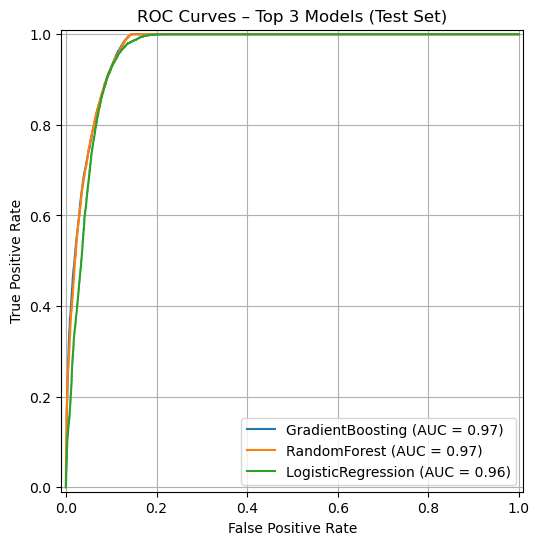

ROC curves saved to: plots/roc_curves_top3_models.png


/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


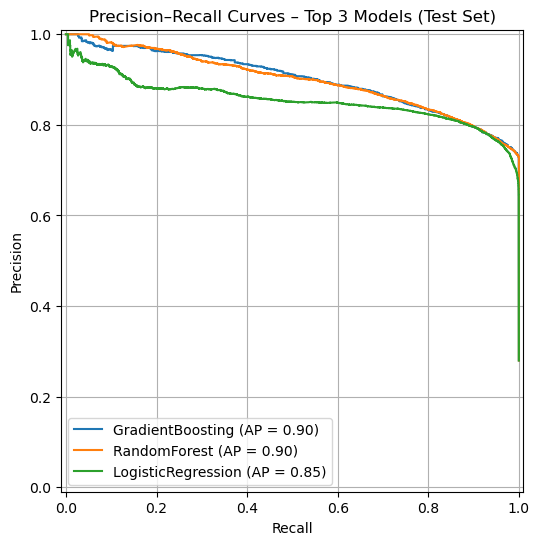

PR curves saved to: plots/pr_curves_top3_models.png


In [24]:
# 11 ROC & PRECISION–RECALL CURVES (TOP 3 MODELS)

import os
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


# Create output folder if it doesn't exist

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

top_model_names = [
    "GradientBoosting",
    "RandomForest",
    "LogisticRegression"
]


# 11.1 ROC CURVES

plt.figure(figsize=(8, 6))

for name in top_model_names:
    model = best_estimators[name]
    RocCurveDisplay.from_estimator(
        model,
        X_test_model,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("ROC Curves – Top 3 Models (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)

roc_path = os.path.join(PLOTS_DIR, "roc_curves_top3_models.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC curves saved to: {roc_path}")



# 11.2 PRECISION–RECALL CURVES

plt.figure(figsize=(8, 6))

for name in top_model_names:
    model = best_estimators[name]
    PrecisionRecallDisplay.from_estimator(
        model,
        X_test_model,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("Precision–Recall Curves – Top 3 Models (Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)

pr_path = os.path.join(PLOTS_DIR, "pr_curves_top3_models.png")
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"PR curves saved to: {pr_path}")


### 12 THRESHOLD TUNING

<div style="background-color:green; padding:12px; border-radius:6px;">
    <span style="color:white; font-size:12px;">
        
        Threshold tuning was performed on the Gradient Boosting model to balance precision and recall for early purchase-intent detection. The optimal threshold was identified at approximately 0.44, which maximizes the F1-score while maintaining a minimum precision of 0.75. At this operating point, the model achieves 95.4% recall, capturing the vast majority of purchasing sessions, while maintaining 77.1% precision, limiting excessive false positives.
        
        The confusion matrix confirms that only a small fraction of purchasers are missed, making this threshold well-suited for proactive intervention use cases where recall is prioritized. The smooth trade-off curves indicate stable model behavior across thresholds, supporting robustness of the selected operating point.
</div>

/opt/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best threshold by F1:
{'threshold': 0.43999999999999995, 'precision': 0.7710379356826497, 'recall': 0.9539011316259678, 'f1': 0.8527767424524786}

Best threshold by Recall:
{'threshold': 0.05, 'precision': 0.6412802688870216, 'recall': 1.0, 'f1': 0.7814390766080238}

Best threshold by F1 with Precision >= 0.75:
{'threshold': 0.43999999999999995, 'precision': 0.7710379356826497, 'recall': 0.9539011316259678, 'f1': 0.8527767424524786}

Saved threshold tuning table to: data/threshold_tuning_gradient_boosting.csv


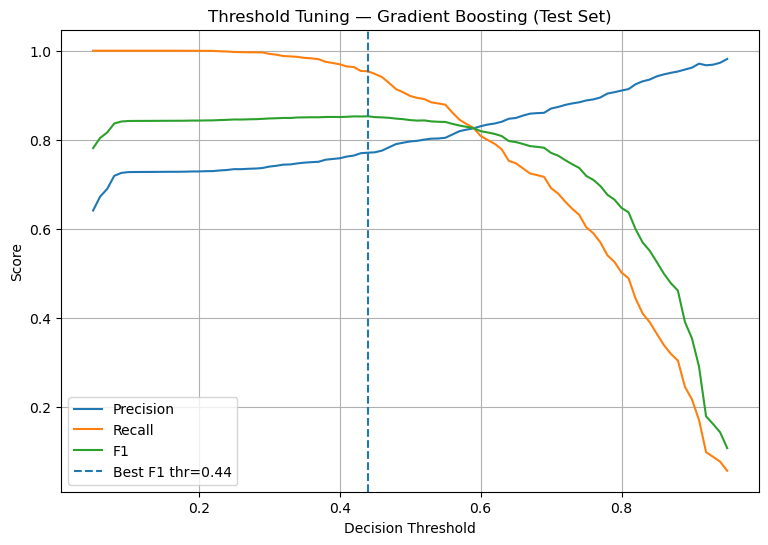

Saved threshold tuning plot to: plots/threshold_tuning_gradient_boosting.png

CONFUSION MATRIX @ threshold=0.44
[[19227  2378]
 [  387  8008]]

CLASSIFICATION REPORT @ threshold=0.44
              precision    recall  f1-score   support

           0     0.9803    0.8899    0.9329     21605
           1     0.7710    0.9539    0.8528      8395

    accuracy                         0.9078     30000
   macro avg     0.8757    0.9219    0.8928     30000
weighted avg     0.9217    0.9078    0.9105     30000



In [26]:
# 12. THRESHOLD TUNING (Gradient Boosting) + SAVE PLOTS + CSV

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

MODEL_NAME = "GradientBoosting"
gb_pipe = best_estimators[MODEL_NAME]

# 12.1 Predicted probabilities on TEST set
y_proba = gb_pipe.predict_proba(X_test_model)[:, 1]

# 12.2 Evaluate metrics across thresholds
thresholds = np.linspace(0.05, 0.95, 91)  # step=0.01
rows = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0)
    })

thr_df = pd.DataFrame(rows)

# 12.3 Pick "best" thresholds based on different objectives
best_f1_row = thr_df.loc[thr_df["f1"].idxmax()]
best_recall_row = thr_df.loc[thr_df["recall"].idxmax()]

# For a "balanced" option: maximize F1 subject to minimum precision (example)
MIN_PRECISION = 0.75
eligible = thr_df[thr_df["precision"] >= MIN_PRECISION]
best_f1_with_min_prec = eligible.loc[eligible["f1"].idxmax()] if len(eligible) else None

print("Best threshold by F1:")
print(best_f1_row.to_dict())

print("\nBest threshold by Recall:")
print(best_recall_row.to_dict())

print(f"\nBest threshold by F1 with Precision >= {MIN_PRECISION}:")
print(best_f1_with_min_prec.to_dict() if best_f1_with_min_prec is not None else "No threshold met the constraint.")

# 12.4 Save threshold table to data folder
DATA_DIR = "data"
csv_path = os.path.join(DATA_DIR, "threshold_tuning_gradient_boosting.csv")

thr_df.to_csv(csv_path, index=False)

print(f"\nSaved threshold tuning table to: {csv_path}")

# 12.5 Plot Precision/Recall/F1 vs Threshold and save PNG
plt.figure(figsize=(9, 6))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="F1")

# Mark best-F1 threshold
plt.axvline(best_f1_row["threshold"], linestyle="--", label=f"Best F1 thr={best_f1_row['threshold']:.2f}")

plt.title("Threshold Tuning — Gradient Boosting (Test Set)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()

plot_path = os.path.join(PLOTS_DIR, "threshold_tuning_gradient_boosting.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved threshold tuning plot to: {plot_path}")

# 12.6 Print confusion matrix + report at chosen threshold (best F1)
chosen_t = float(best_f1_row["threshold"])
y_pred_best = (y_proba >= chosen_t).astype(int)

print(f"\nCONFUSION MATRIX @ threshold={chosen_t:.2f}")
print(confusion_matrix(y_test, y_pred_best))

print(f"\nCLASSIFICATION REPORT @ threshold={chosen_t:.2f}")
print(classification_report(y_test, y_pred_best, digits=4))


### 13 FEATURE IMPORTANCE

<div style="background-color:green; padding:12px; border-radius:6px;">
    <span style="color:white; font-size:12px;">
        
    Feature importance analysis from the Gradient Boosting model indicates that behavioral engagement metrics—specifically page views and number of events—drive the majority of predictive power. Session duration and product breadth provide modest incremental value, while demographic and acquisition attributes contribute minimally. This reinforces the conclusion that real-time engagement intensity is the primary determinant of purchase intent.

</div>

,feature,importance
3,num__page_view,0.497313
1,num__n_events,0.477023
0,num__session_duration_min,0.012240
2,num__n_distinct_products,0.011233
4,num__age,0.000149
90192,cat__signup_date_2020-07-12,0.000099
91398,cat__signup_date_2023-10-31,0.000084
91475,cat__signup_date_2024-01-16,0.000083
90359,cat__signup_date_2020-12-26,0.000057
91220,cat__signup_date_2023-05-06,0.000055


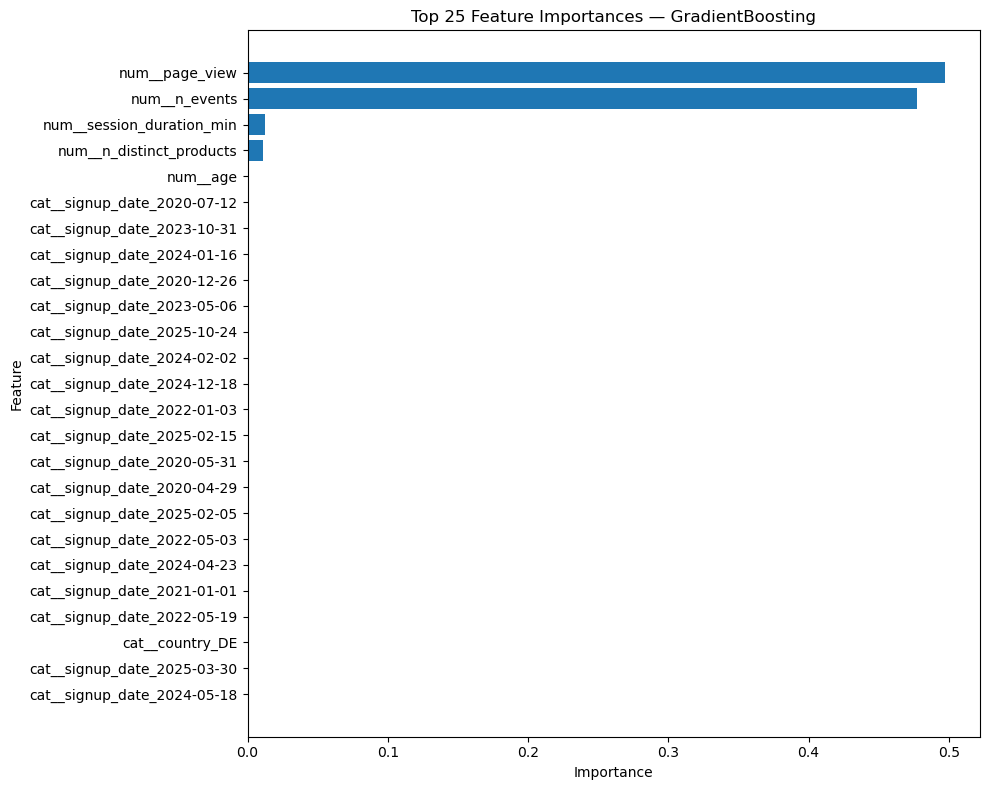

Saved feature importance plot to: plots/feature_importance_gradientboosting_top25.png


In [25]:
# 12. FEATURE IMPORTANCE (Gradient Boosting) + SAVE PNG
# Works with Pipeline: ("preprocess", preprocessor) -> ("model", GradientBoostingClassifier)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

MODEL_NAME = "GradientBoosting"   # key in best_estimators
TOP_N = 25                        # change to show more/less

gb_pipe = best_estimators[MODEL_NAME]

# 12.1 Get feature names after preprocessing (numeric + one-hot)
pre = gb_pipe.named_steps["preprocess"]
feature_names = pre.get_feature_names_out()

# 12.2 Get feature importances from the trained GradientBoosting model
gb_model = gb_pipe.named_steps["model"]

if not hasattr(gb_model, "feature_importances_"):
    raise ValueError("This model does not expose feature_importances_.")

importances = gb_model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi.head(TOP_N))

# 12.3 Plot Top N importances
top_fi = fi.head(TOP_N).iloc[::-1]  # reverse for horizontal bar plot (largest at top)

plt.figure(figsize=(10, 8))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title(f"Top {TOP_N} Feature Importances — {MODEL_NAME}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

outpath = os.path.join(PLOTS_DIR, f"feature_importance_{MODEL_NAME.lower()}_top{TOP_N}.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved feature importance plot to: {outpath}")


**END** 